In [1]:
!pip install diffusers transformers accelerate safetensors
!pip install torch torchvision               # GPU ランタイムなら不要かも
!pip install pillow matplotlib requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 60.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [2]:
# -----------------------------------------
# Imports & Setup
# -----------------------------------------
import torch
from diffusers import StableDiffusionInpaintPipeline
from PIL import Image, ImageDraw
import requests
from io import BytesIO
import matplotlib.pyplot as plt

# 再現性のため乱数固定
torch.manual_seed(0)

# 使用デバイスと dtype の選択
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype  = torch.float16 if device=="cuda" else torch.float32

# -----------------------------------------
# 1. Stable Diffusion Inpainting パイプラインのロード
# -----------------------------------------
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "stabilityai/stable-diffusion-2-inpainting",
    torch_dtype=dtype,
    safety_checker=None
).to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/544 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

merges.txt: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/914 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.46G [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

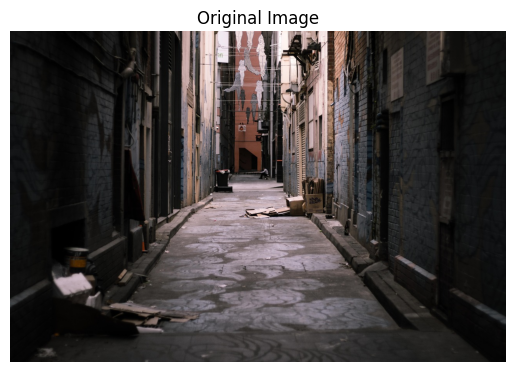

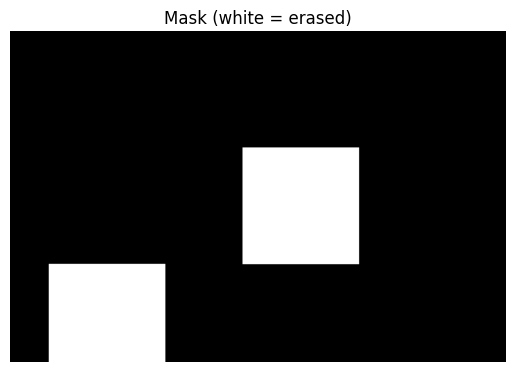

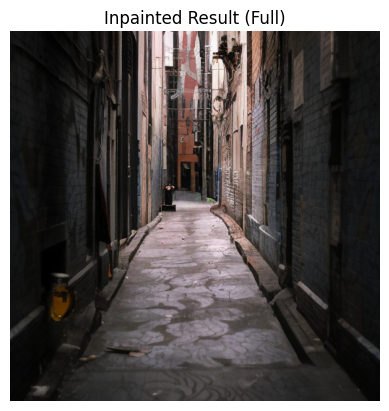

In [5]:
# -----------------------------------------
# 2. ライセンスフリー画像の取得
# -----------------------------------------
url = "https://cdn.pixabay.com/photo/2018/11/26/10/43/ally-3839139_1280.jpg"
resp = requests.get(url)
orig = Image.open(BytesIO(resp.content)).convert("RGB")

# -----------------------------------------
# 3. マスク画像の作成（白＝消去領域、黒＝保持領域）
# -----------------------------------------
mask = Image.new("L", orig.size, 0)
draw = ImageDraw.Draw(mask)
# Mask 1
tlx, tly, width, height = 100, 600, 300, 350
draw.rectangle([tlx, tly, tlx + width, tly + height], fill=255)
# Mask 2
tlx, tly, width, height = 600, 300, 300, 300
draw.rectangle([tlx, tly, tlx + width, tly + height], fill=255)

# -----------------------------------------
# 4. Inpainting 実行
# -----------------------------------------
generator = torch.Generator(device=device).manual_seed(0)
result = pipe(
    prompt="",
    image=orig,
    mask_image=mask,
    guidance_scale=7.5,
    generator=generator
).images[0]

# # -----------------------------------------
# # 5. 重ね合わせた画像の作成
# # -----------------------------------------
# # 元の画像のコピーを作成
# overlayed_result = orig.copy()
# # pasteメソッドを使い、マスク領域（白の部分）にだけInpainting結果を貼り付け
# overlayed_result.paste(result, mask=mask)

# -----------------------------------------
# 6. 結果の表示（各 figure を個別に出力）
# -----------------------------------------
for title, img in [
    ("Original Image", orig),
    ("Mask (white = erased)", mask),
    ("Inpainted Result (Full)", result), # Inpaintingの生の結果
    # ("Overlayed Result", overlayed_result)  # 重ね合わせた結果を追加
]:
    plt.figure()
    if img.mode=="L":
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()